# Analiza podatkov

Notebook je razdeljen na dva dela:
1. **Osnovne statistike** — pregled podatkovne zbirke in ključne informacije
2. **Vprašanja** — poglobljene analize posameznih vprašanj

## Knjižnice in vizualni stil

Uvozimo potrebne knjižnice in nastavimo enoten stil grafov, da bodo vizualizacije po celotnem notebooku konsistentne.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

# Matplotlib stil
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "grid.color": "#E0E0E0",
})

COLORS = plt.cm.tab10.colors

## Nalaganje podatkov

Naložimo obe podatkovni datoteki: `data.csv` z oglasi in `changes.csv` z zaznanimi spremembami. Podrobnejši opis strukture podatkov je v datoteki `reports/osnutek.md`.

In [2]:
DATA_DIR = Path("../../data")
data = pd.read_csv(DATA_DIR / "data.csv", parse_dates=["first_seen", "last_seen", "start_date"])
changes = pd.read_csv(DATA_DIR / "changes.csv", parse_dates=["changed_at"])

# Osnovne statistike

Spodaj so prikazane ključne lastnosti podatkovne zbirke: velikost in obdobje zbiranja, porazdelitev neto urnih postavk, število novih oglasov na dan, razporeditev po regijah, tipi plačila, najpogostejši delodajalci, delovni čas, število prostih mest ter najpogostejša mesta.

In [3]:
# Pregled dataseta
pregled = pd.DataFrame({
    "Metrika": [
        "Število oglasov",
        "Obdobje zbiranja",
        "Zaznanih sprememb",
    ],
    "Vrednost": [
        f"{len(data):,}",
        f"{data['first_seen'].min().date()} — {data['last_seen'].max().date()}",
        f"{len(changes):,}",
    ],
})
display(pregled.style.hide(axis="index").set_properties(**{"text-align": "left"}))

# Pokritost polj
pokritost = (
    (1 - data.isnull().mean())
    .to_frame("Pokritost")
    .rename_axis("Polje")
)
display(Markdown("#### Pokritost polj"))
display(pokritost.style.format("{:.0%}"))

Metrika,Vrednost
Število oglasov,"4,423"
Obdobje zbiranja,2026-03-12 — 2026-04-10
Zaznanih sprememb,"1,627"


#### Pokritost polj

,Pokritost
Polje,
id,100%
title,100%
subtitle,41%
company,100%
location,100%
sublocation,40%
hourly_rate_neto,93%
hourly_rate_bruto,93%
payment_type,100%


### Neto urne postavke

Statistika urnih postavk je izračunana samo za oglase s tipom plačila **HOURLY**, kjer je urna postavka smiselno definirana.

,Neto urna postavka (€)
Število oglasov,4120.00
Povprečje,8.69
Std. odklon,1.81
Min,7.73
25%,7.73
Mediana (50%),8.00
75%,9.00
Max,60.00


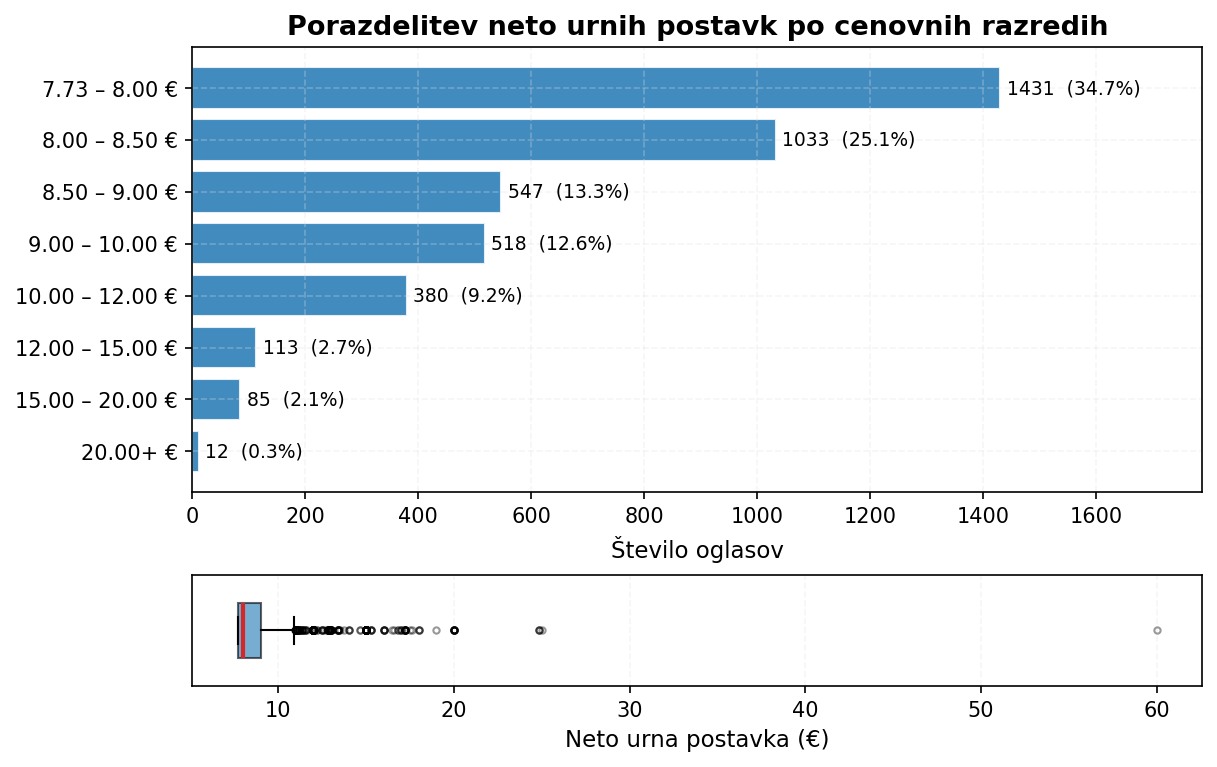

In [4]:
# Filtriramo samo oglase z urnim plačilom
hourly = data[data["normalized_payment_type"] == "HOURLY"].copy()
rates = hourly["hourly_rate_neto"].dropna()
MIN_WAGE = 7.73  # minimalna študentska urna postavka (neto)

# Opisna statistika
stats = rates.describe().to_frame("Neto urna postavka (€)")
stats.index = ["Število oglasov", "Povprečje", "Std. odklon", "Min", "25%", "Mediana (50%)", "75%", "Max"]
display(stats.style.format("{:.2f}"))

# Frekvenčna tabela po cenovnih razredih (od minimalne plače naprej)
bins = [MIN_WAGE, 8, 8.5, 9, 10, 12, 15, 20, 30]
labels = ["7.73 – 8.00 €", "8.00 – 8.50 €", "8.50 – 9.00 €",
          "9.00 – 10.00 €", "10.00 – 12.00 €", "12.00 – 15.00 €",
          "15.00 – 20.00 €", "20.00+ €"]
razredi = pd.cut(rates, bins=bins, labels=labels, right=False)
freq = razredi.value_counts().sort_index().to_frame("Število oglasov")
freq["Delež"] = freq["Število oglasov"] / freq["Število oglasov"].sum()

# Stolpčni graf razredov + box plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), layout="constrained",
                               gridspec_kw={"height_ratios": [4, 1]})

bars = ax1.barh(labels, freq["Število oglasov"], color=COLORS[0], edgecolor="white", alpha=0.85)
ax1.bar_label(bars, labels=[f"{v}  ({p:.1%})" for v, p in zip(freq["Število oglasov"], freq["Delež"])],
              padding=3, fontsize=9)
ax1.set_xlabel("Število oglasov")
ax1.set_title("Porazdelitev neto urnih postavk po cenovnih razredih")
ax1.set_xlim(right=freq["Število oglasov"].max() * 1.25)
ax1.invert_yaxis()

# Box plot pod stolpčnim grafom
bp = ax2.boxplot(rates, vert=False, widths=0.5, patch_artist=True,
                 boxprops=dict(facecolor=COLORS[0], alpha=0.6),
                 medianprops=dict(color=COLORS[3], linewidth=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax2.set_xlabel("Neto urna postavka (€)")
ax2.set_yticks([])

plt.show()

### Število novih oglasov na dan

Koliko novih oglasov se pojavi na portalu vsak dan? Prvi dan zbiranja izpustimo, ker je scraper takrat pobral vse že obstoječe oglase naenkrat.

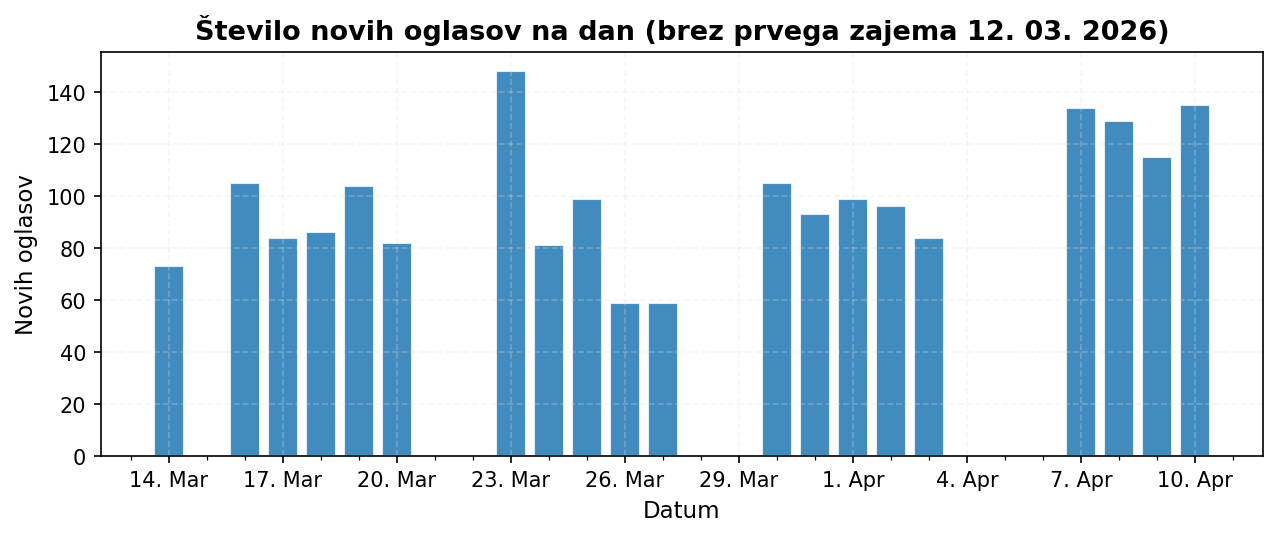

In [5]:
import matplotlib.dates as mdates
import platform

# Število novih oglasov po dnevu (first_seen = kdaj smo oglas prvič videli)
daily_new = data.groupby(data["first_seen"].dt.date).size()

# Izpustimo prvi dan — takrat je scraper pobral vse obstoječe oglase
first_day = daily_new.index.min()
daily_new = daily_new.drop(first_day)

# Pretvorimo datume za matplotlib formatting
dates = pd.to_datetime(daily_new.index)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(dates, daily_new.values, color=COLORS[0], edgecolor="white", alpha=0.85, width=0.8)

# TODO: ob večanju podatkov moramo ustrezno podaljašti inerval prikaza oznake datuma
# Prikažemo vsak 2. dan kot oznako, format "11. mar"
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
fmt = "%#d. %b" if platform.system() == "Windows" else "%-d. %b"  #formatiranje tako deluje pravilno neodvisno od sistema
ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))
ax.xaxis.set_minor_locator(mdates.DayLocator())

ax.set_xlabel("Datum")
ax.set_ylabel("Novih oglasov")
ax.set_title(f"Število novih oglasov na dan (brez prvega zajema {first_day:%d. %m. %Y})")
plt.xticks(rotation=0)
plt.show()

### Oglasi po regijah

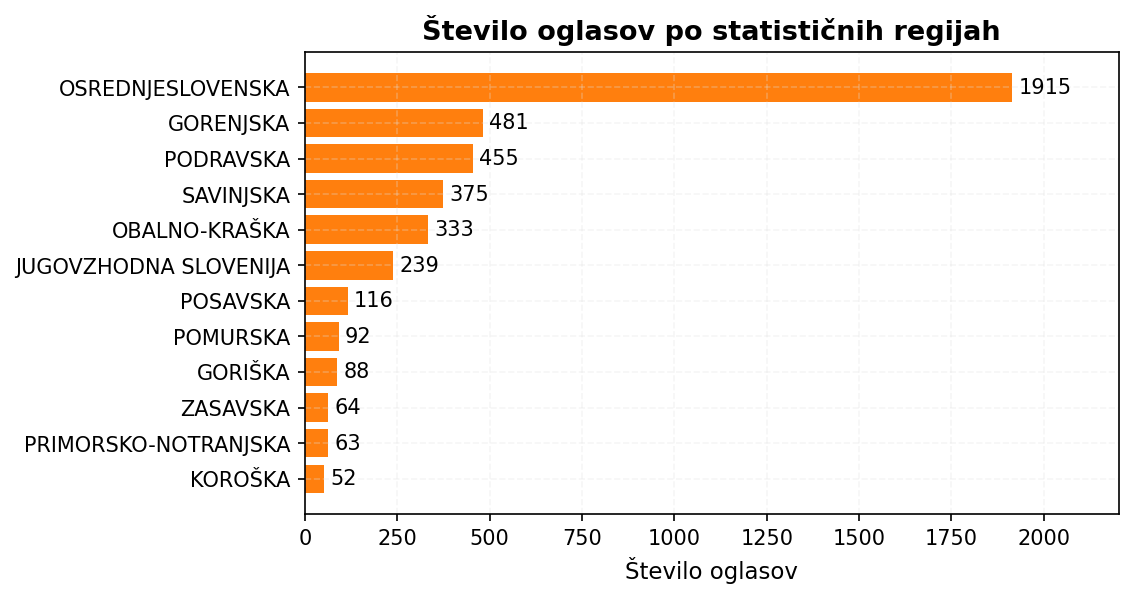

In [6]:
region_counts = data["normalized_region"].value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(region_counts.index, region_counts.values, color=COLORS[1])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Število oglasov po statističnih regijah")
ax.set_xlim(right=region_counts.max() * 1.15)
plt.show()

### Tipi plačila

Stolpec `normalized_payment_type` razvršča oglase glede na način izplačila:

| Tip | Slovensko         | Pomen |
|---|-------------------|---|
| `HOURLY` | Urna postavka     | Plačilo na uro dela |
| `NEGOTIABLE` | Po dogovoru       | Plačilo ni vnaprej določeno, dogovor med delodajalcem in študentom |
| `PROJECT` | Projektno plačilo | Fiksno plačilo za celoten projekt ali nalogo |
| `PER_EVENT` | Na dogodek        | Plačilo na posamezen dogodek (npr. promocija, animacija) |
| `PER_TRIP` | Na izlet          | Plačilo na izlet |
| `OTHER` | Drugo             | Netipičen ali nerazpoznan način plačila |

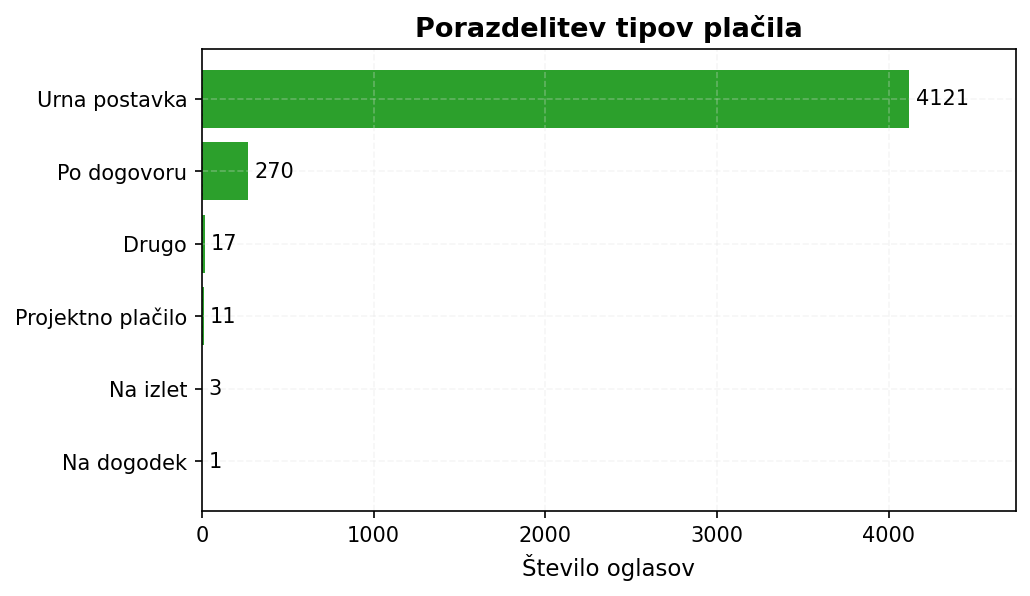

In [7]:
# Mapiramo angleška imena v slovenska
PAYMENT_LABELS = {
    "HOURLY": "Urna postavka",
    "NEGOTIABLE": "Po dogovoru",
    "PROJECT": "Projektno plačilo",
    "PER_EVENT": "Na dogodek",
    "PER_TRIP": "Na izlet",
    "OTHER": "Drugo",
}

payment_counts = data["normalized_payment_type"].map(PAYMENT_LABELS).value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(payment_counts.index, payment_counts.values, color=COLORS[2])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Porazdelitev tipov plačila")
ax.set_xlim(right=payment_counts.max() * 1.15)
plt.show()

### Top 10 delodajalcev po številu oglasov

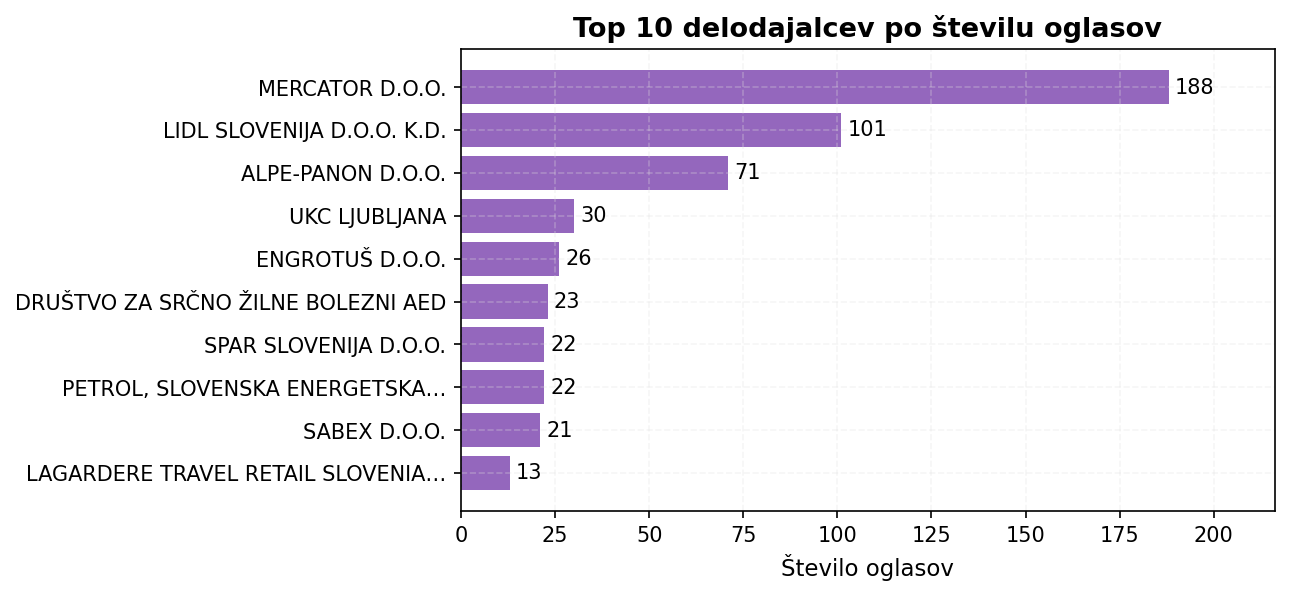

In [8]:
import textwrap

top_companies = data["company"].value_counts().head(10).sort_values()

# Skrajšamo predolga imena (>35 znakov)
short_names = top_companies.index.map(lambda x: textwrap.shorten(x, width=35, placeholder="…"))

fig, ax = plt.subplots()
bars = ax.barh(short_names, top_companies.values, color=COLORS[4])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Top 10 delodajalcev po številu oglasov")
ax.set_xlim(right=top_companies.max() * 1.15)
plt.show()

### Delovni čas

Kako so oglasi porazdeljeni glede na delovni čas? Stolpec `work_schedule` označuje, kdaj se delo izvaja — dopoldan, popoldan, izmensko, med vikendi ali po dogovoru.

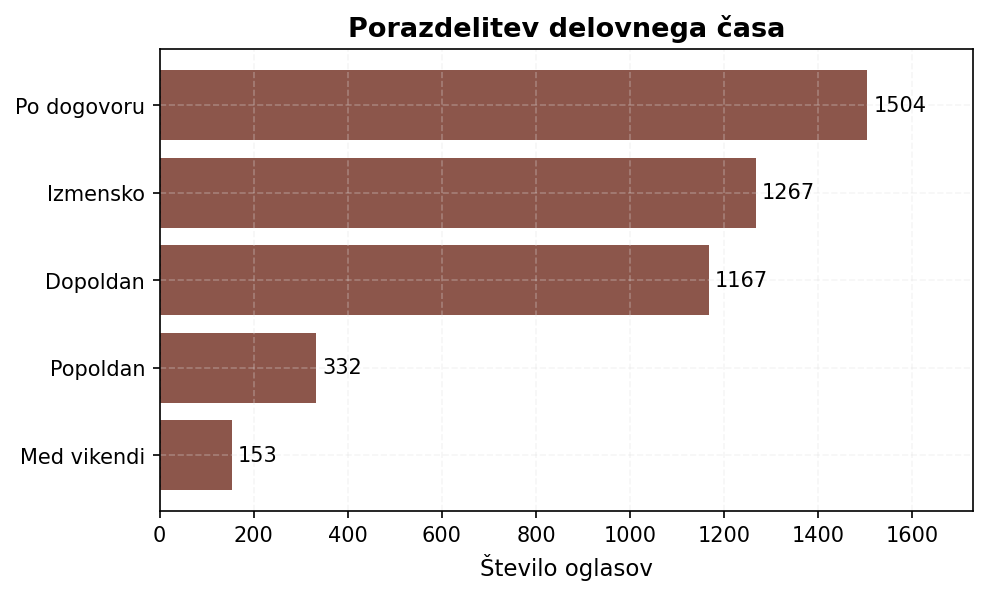

In [9]:
# Porazdelitev delovnega časa
SCHEDULE_LABELS = {
    "PO DOGOVORU": "Po dogovoru",
    "DOPOLDAN": "Dopoldan",
    "POPOLDAN": "Popoldan",
    "IZMENSKO": "Izmensko",
    "MED VIKENDI": "Med vikendi",
}

schedule_counts = data["work_schedule"].map(SCHEDULE_LABELS).value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(schedule_counts.index, schedule_counts.values, color=COLORS[5])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Porazdelitev delovnega časa")
ax.set_xlim(right=schedule_counts.max() * 1.15)
plt.show()

### Število prostih mest

Vsak oglas ima lahko podatek o številu prostih mest (`open_positions`). To pove, koliko študentov delodajalec dejansko išče — en oglas lahko pomeni povpraševanje po več delavcih.

In [10]:
# Število prostih mest — koliko študentov dejansko iščejo
positions = data["open_positions"].dropna()

povzetek_mest = pd.DataFrame({
    "Metrika": [
        "Oglasov s podatkom o prostih mestih",
        "Skupno prostih mest",
        "Povprečje na oglas",
        "Mediana na oglas",
        "Največ prostih mest v enem oglasu",
    ],
    "Vrednost": [
        f"{len(positions):,.0f} od {len(data):,.0f} ({len(positions) / len(data) * 100:.0f}%)",
        f"{positions.sum():,.0f}",
        f"{positions.mean():.1f}",
        f"{positions.median():.0f}",
        f"{positions.max():.0f}",
    ],
})
display(povzetek_mest.style.hide(axis="index").set_properties(**{"text-align": "left"}))

# Top 10 oglasov z največ prostimi mesti
top_positions = (
    data.dropna(subset=["open_positions"])
    .nlargest(10, "open_positions")
    [["title", "company", "normalized_city", "open_positions"]]
    .rename(columns={
        "title": "Naslov", "company": "Delodajalec",
        "normalized_city": "Mesto", "open_positions": "Prostih mest",
    })
)
top_positions["Naslov"] = top_positions["Naslov"].apply(
    lambda x: textwrap.shorten(x, 50) if isinstance(x, str) else x)
top_positions["Delodajalec"] = top_positions["Delodajalec"].apply(
    lambda x: textwrap.shorten(x, 35) if isinstance(x, str) else x)

display(Markdown("#### Top 10 oglasov z največ prostimi mesti"))
display(top_positions.style.hide(axis="index").format({"Prostih mest": "{:.0f}"}, na_rep="Ni podatka"))

Metrika,Vrednost
Oglasov s podatkom o prostih mestih,"2,082 od 4,423 (47%)"
Skupno prostih mest,"7,054"
Povprečje na oglas,3.4
Mediana na oglas,2
Največ prostih mest v enem oglasu,40


#### Top 10 oglasov z največ prostimi mesti

Naslov,Delodajalec,Mesto,Prostih mest
RAZISKOVALNO DELO,PEDAGOŠKI INŠTITUT,Ni podatka,40
STATIST,"CUT PRODUCTION, TV [...]",LJUBLJANA,30
DELO V KUHINJI,ALPE-PANON D.O.O.,PTUJ,25
DELO S STRANKAMI,ALPE-PANON D.O.O.,PTUJ,25
STREŽBA,VANUM'S D.O.O.,ZREČE,20
DELO Z OTROKI,VARNA POT,LJUBLJANA,20
ANIMATOR/KA,VARNA POT,LJUBLJANA,20
PROMOCIJA,VARNA POT,Ni podatka,20
BLAGAJNIK,"GLOBAL FAST FOOD S, D.O.O.",CELJE,20
DELO V TURIZMU,RELAX TURIZEM D.D.,Ni podatka,20


### Top 10 mest po številu oglasov

Podrobnejši pogled na lokacijo oglasov — namesto statističnih regij pogledamo posamezna mesta (`normalized_city`).

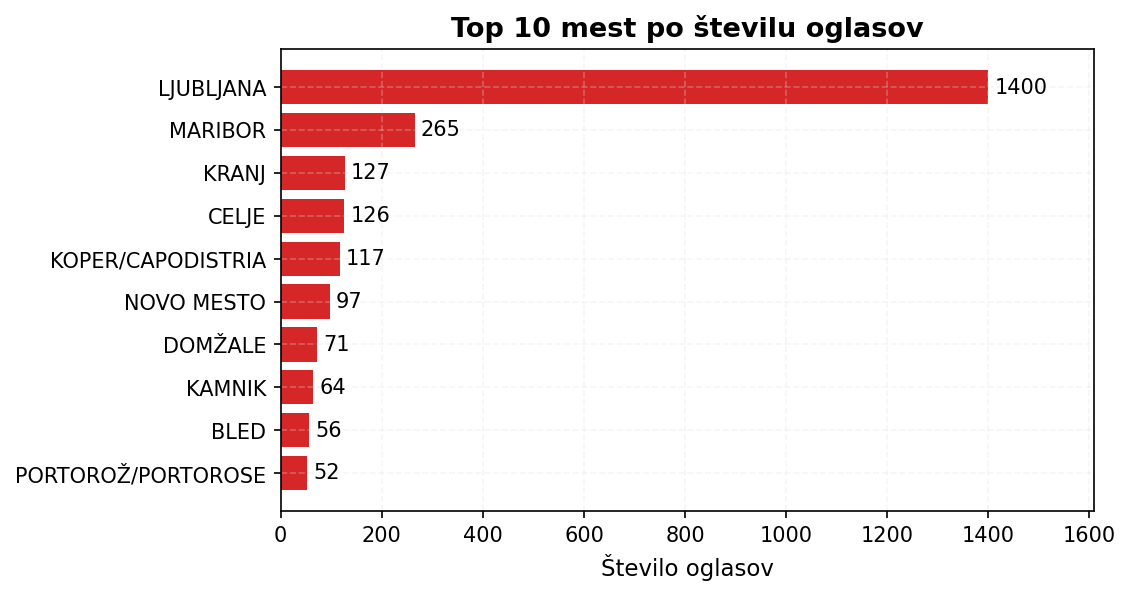

In [11]:
# Top 10 mest po številu oglasov
city_counts = data["normalized_city"].value_counts().head(10).sort_values()

fig, ax = plt.subplots()
bars = ax.barh(city_counts.index, city_counts.values, color=COLORS[3])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Top 10 mest po številu oglasov")
ax.set_xlim(right=city_counts.max() * 1.15)
plt.show()

---

# Vprašanja

Vsako vprašanje sledi enaki strukturi: **naslov**, **opis**, **analiza**, **vizualizacija** in **ugotovitve**.

## Template za vprašanja

Vsako vprašanje v razdelku **Vprašanja** mora slediti spodnji strukturi:

```
## Vprašanje [N]: [Kratek, jasen naslov]

### Opis
Kaj točno raziskujemo? Zakaj je to vprašanje relevantno? Katere stolpce/podatke
uporabljamo in kakšna je hipoteza, če jo imamo?

### Analiza
[code celica — priprava podatkov, izračuni, tabele]

### Vizualizacija
[code celica — grafi]

### Ugotovitve
- Kaj smo ugotovili?
- Ali se hipoteza potrdi ali ne?
- Kakšne so omejitve analize?
```

## Vprašanje 1: Popularnost programskih (in ostalih) jezikov v opisih oglasov

### Opis

Zanima nas, kateri programski (in ostali) jeziki se najpogosteje pojavljajo v besedilnih opisih študentskih oglasov. S preprosto regex analizo polja `description` iščemo omembe 10 popularnih jezikov (Python, JavaScript, Java, C++, C#, PHP, SQL, TypeScript, HTML, CSS). Rezultat je groba ocena povpraševanja po posameznih jezikih na trgu študentskega dela.

**Omejitev:** Analiza šteje le eksplicitne omembe — oglas za "spletno programiranje" brez navedbe jezika ne bo zajet.

### Analiza

In [12]:
# Regex vzorci za 10 popularnih jezikov
# \b = word boundary, (?!\w) = ne sme slediti črka/številka
# C# in C++ potrebujeta (?!\w) namesto \b ker # in + niso word characters
# [aeiou]? na koncu ujame slovenske sklone (Pythona, Javo, ...)
# Kratice (HTML, CSS, ...) dobijo (?:j?[aeiou])? ker se sklanjajo z j: HTMLja, CSSju
# SQL ujame tudi MySQL, PostgreSQL in MariaDB — vse štejemo pod "SQL"
# JavaScript ujame tudi Node.js / NodeJS — isti jezik, drug runtime
languages = {
    "Python": r"\bPython[aeiou]?\b",
    "JavaScript": r"\bJavaScript[aeiou]?\b|\bNode(?:\.?js|JS)\b",
    "PHP": r"\bPHP(?:j?[aeiou])?\b",
    "SQL": r"\b(?:My|Postgre)?SQL(?:j?[aeiou])?\b|\bMariaDB\b",
    "Java": r"\bJav[aeiou]\b(?!Script)",  # Java/Javo/Jave/Javi — vedno ima samoglasnik
    "C#": r"\bC#(?![a-zA-Z0-9])",  # \b ne deluje za # ker ni word char
    "C++": r"\bC\+\+(?![a-zA-Z0-9])",  # isto za +
    "TypeScript": r"\bTypeScript[aeiou]?\b",
    "HTML": r"\bHTML(?:j?[aeiou])?\b",
    "CSS": r"\bCSS(?:j?[aeiou])?\b",
}

# Preštejemo v koliko oglasih se pojavi vsak jezik (case-insensitive)
desc = data["description"].fillna("")
counts = {
    lang: desc.str.contains(pat, case=False, regex=True).sum()
    for lang, pat in languages.items()
}

# Rezultat kot DataFrame, sortirano naraščajoče za barh graf
lang_df = (
    pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
    .sort_values("count", ascending=True)
)
lang_df = lang_df[lang_df["count"] > 0]  # prikažemo samo jezike ki se dejansko pojavljajo

lang_df

,count
PHP,2
TypeScript,2
CSS,5
C#,6
HTML,6
C++,7
JavaScript,8
SQL,9
Python,16
Java,23


In [13]:
# Koliko oglasov omenja vsaj en programski jezik?
combined_pattern = "|".join(languages.values())
total_with_lang = desc.str.contains(combined_pattern, case=False, regex=True).sum()

povzetek = pd.DataFrame({
    "Metrika": [
        "Oglasov z omembo vsaj enega jezika",
        "Delež vseh oglasov",
        "Najbolj iskan jezik",
    ],
    "Vrednost": [
        f"{total_with_lang} od {len(data)}",
        f"{total_with_lang / len(data) * 100:.1f}%",
        f"{lang_df.index[-1]} ({lang_df['count'].iloc[-1]} oglasov)",
    ],
})
display(povzetek.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Metrika,Vrednost
Oglasov z omembo vsaj enega jezika,47 od 4423
Delež vseh oglasov,1.1%
Najbolj iskan jezik,Java (23 oglasov)


### Vizualizacija

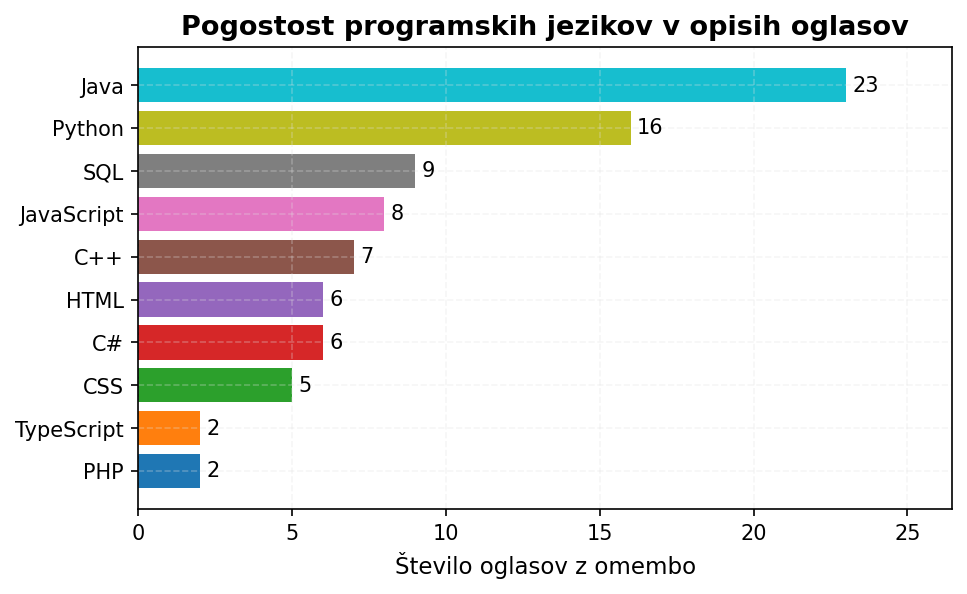

In [14]:
# Horizontalni stolpčni graf — vsak jezik svoja barva za boljšo ločljivost
fig, ax = plt.subplots()
bars = ax.barh(lang_df.index, lang_df["count"], color=COLORS[: len(lang_df)])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov z omembo")
ax.set_title("Pogostost programskih jezikov v opisih oglasov")
ax.set_xlim(right=lang_df["count"].max() * 1.15)
plt.show()

### Ugotovitve

- Kateri jezik prevladuje in zakaj je to pričakovano/presenetljivo?
- Kolikšen delež oglasov sploh omenja programski jezik?

## Vprašanje 2: Ali delodajalci dvigujejo plače, ko oglasa ne morejo zapolniti?

### Opis

Datoteka `changes.csv` beleži vsako spremembo polja na obstoječem oglasu. Če delodajalec po objavi dvigne urno postavko (`hourly_rate_neto`), je to signal, da prvotna ponudba ni pritegnila dovolj kandidatov.

Analiziramo:
- Koliko oglasov je doživelo dvig plače in koliko znižanje?
- Po koliko dneh od objave se tipično zgodi dvig?
- Za koliko se plača dvigne — minimalen popravek ali občuten skok?

**Hipoteza:** Večina sprememb bo dvigov (ne znižanj), do katerih pride v prvih dneh po objavi.

### Analiza

In [15]:
# Iz changes.csv izvlečemo samo spremembe urne postavke
rate_changes = changes[changes["field"] == "hourly_rate_neto"].copy()

# Pretvorimo staro in novo vrednost v številke
rate_changes["old_value"] = pd.to_numeric(rate_changes["old_value"], errors="coerce")
rate_changes["new_value"] = pd.to_numeric(rate_changes["new_value"], errors="coerce")
rate_changes = rate_changes.dropna(subset=["old_value", "new_value"])

# Izračunamo razliko (pozitivna = dvig, negativna = znižanje)
rate_changes["diff"] = rate_changes["new_value"] - rate_changes["old_value"]

# Koliko dni po prvi objavi oglasa je prišlo do spremembe
rate_changes = rate_changes.merge(
    data[["id", "first_seen"]],
    left_on="listing_id", right_on="id", how="left"
)
rate_changes["days_after_post"] = (rate_changes["changed_at"] - rate_changes["first_seen"]).dt.days

# Ločimo dvige in znižanja
raises = rate_changes[rate_changes["diff"] > 0]
cuts = rate_changes[rate_changes["diff"] < 0]

# Povzetek v tabeli
povzetek = pd.DataFrame({
    "Metrika": [
        "Sprememb urne postavke skupaj",
        "Dvigov plače",
        "Znižanj plače",
        "Povprečen dvig (€)",
        "Mediana dni do dviga",
    ],
    "Vrednost": [
        f"{len(rate_changes)}",
        f"{len(raises)} ({len(raises) / len(rate_changes) * 100:.0f}%)" if len(rate_changes) > 0 else "0",
        f"{len(cuts)} ({len(cuts) / len(rate_changes) * 100:.0f}%)" if len(rate_changes) > 0 else "0",
        f"{raises['diff'].mean():.2f} €" if len(raises) > 0 else "—",
        f"{raises['days_after_post'].median():.0f} dni" if len(raises) > 0 else "—",
    ],
})
display(povzetek.style.hide(axis="index").set_properties(**{"text-align": "left"}).format(na_rep="Ni podatka"))

Metrika,Vrednost
Sprememb urne postavke skupaj,87
Dvigov plače,87 (100%)
Znižanj plače,0 (0%)
Povprečen dvig (€),0.96 €
Mediana dni do dviga,15 dni


### Vizualizacija

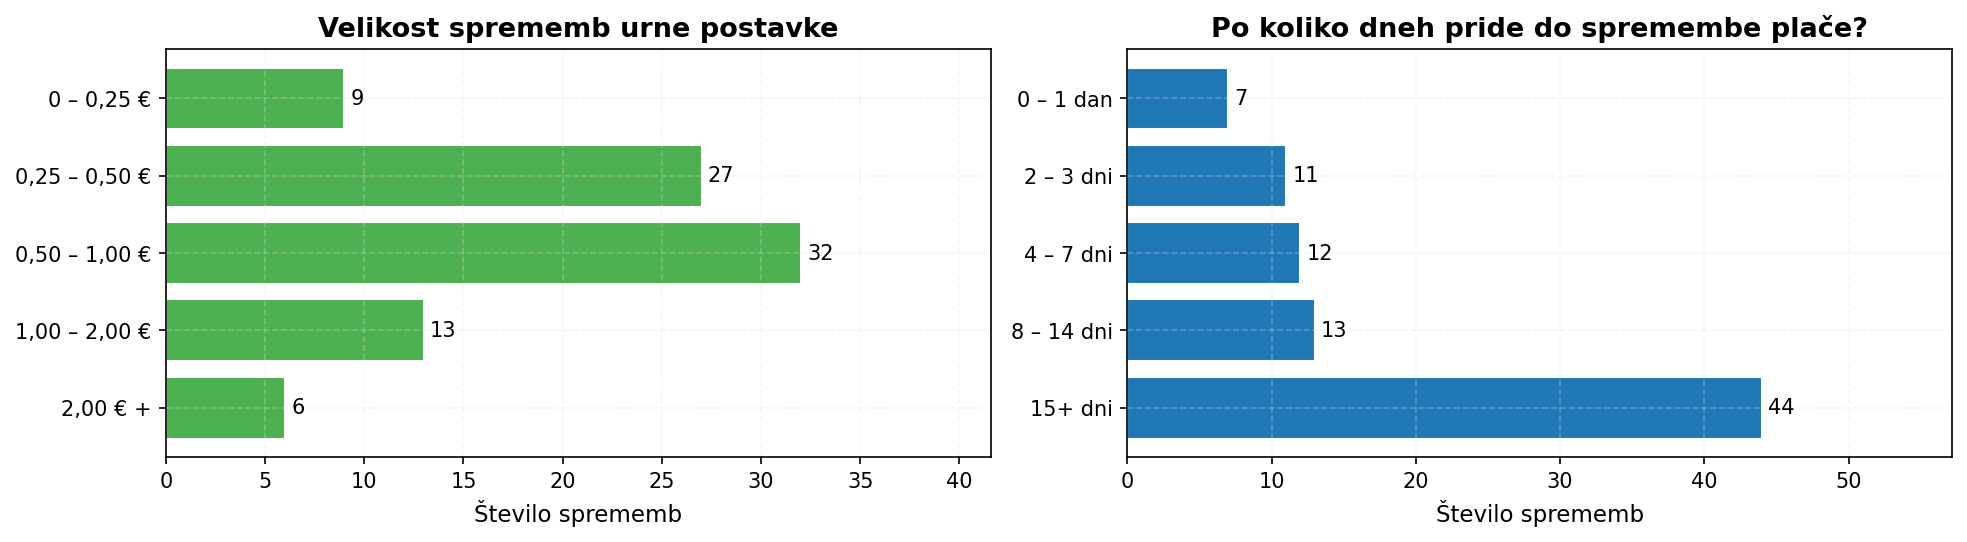

#### Top 10 največjih dvigov

Naslov,Delodajalec,Prej (€),Potem (€),Dvig (€),Dni po objavi
ČIŠČENJE,"ARTHA 9, INOVATIVNE REŠITVE, D.O.O.",12.00,18.00,+6.00,15
ČIŠČENJE,"ARTHA 9, INOVATIVNE REŠITVE, D.O.O.",12.00,18.00,+6.00,15
DELO NA BENCINSKEM SERVISU,POSREDNIŠTVO PRI PRODAJI UROŠ [...],10.00,13.00,+3.00,24
DELO NA TERENU,"ENERGETIKA LJUBLJANA, D.O.O.",7.74,10.33,+2.59,10
DELO S STRANKAMI,"GLOBAL FAST FOOD S, D.O.O.",8.17,10.76,+2.59,3
BLAGAJNIK,LAGARDERE TRAVEL RETAIL [...],7.74,9.90,+2.16,15
STREŽBA,"PREVOZI, ŠPEDICIJA IN [...]",8.00,10.00,+2.00,3
DELO V ZDRAVSTVU,KIRURGIJA ERNEST NOVAK S.P.,8.00,10.00,+2.00,7
STREŽBA HRANE IN PIJAČE,LIR D.O.O.,8.00,10.00,+2.00,17
STREŽBA,"POSREDNIŠTVO PRI PRODAJI, [...]",10.00,12.00,+2.00,6


In [16]:
# --- Graf 1: Velikost sprememb urne postavke (intervali) ---
bins_size = [0, 0.25, 0.50, 1.00, 2.00, float("inf")]
labels_size = ["0 – 0,25 €", "0,25 – 0,50 €", "0,50 – 1,00 €", "1,00 – 2,00 €", "2,00 € +"]

# --- Graf 2: Po koliko dneh pride do spremembe ---
bins_days = [-1, 1, 3, 7, 14, float("inf")]
labels_days = ["0 – 1 dan", "2 – 3 dni", "4 – 7 dni", "8 – 14 dni", "15+ dni"]

if len(rate_changes) > 0:
    # Razdelimo spremembe v intervale glede na absolutno vrednost
    rate_changes["abs_diff"] = rate_changes["diff"].abs()
    rate_changes["interval_size"] = pd.cut(rate_changes["abs_diff"], bins=bins_size, labels=labels_size, right=True)
    rate_changes["interval_days"] = pd.cut(rate_changes["days_after_post"], bins=bins_days, labels=labels_days,
                                           right=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5), layout="constrained")

    # --- Levi graf: velikost sprememb ---
    raises_binned = rate_changes[rate_changes["diff"] > 0].groupby("interval_size", observed=False).size()
    cuts_binned = rate_changes[rate_changes["diff"] < 0].groupby("interval_size", observed=False).size()

    bars_r = ax1.barh(labels_size, raises_binned.values, color="#4CAF50", edgecolor="white", label="Dvig ↑")
    ax1.bar_label(bars_r, padding=3, fontsize=10)

    if cuts_binned.sum() > 0:
        bars_c = ax1.barh(labels_size, cuts_binned.values, left=raises_binned.values,
                          color="#E53935", edgecolor="white", label="Znižanje ↓")
        ax1.bar_label(bars_c, padding=3, fontsize=10)
        ax1.legend(loc="lower right")

    ax1.set_xlabel("Število sprememb")
    ax1.set_title("Velikost sprememb urne postavke")
    ax1.set_xlim(right=max(raises_binned.max(), 1) * 1.3)
    ax1.invert_yaxis()

    # --- Desni graf: dni do spremembe ---
    days_binned = rate_changes.groupby("interval_days", observed=False).size()

    bars_d = ax2.barh(labels_days, days_binned.values, color=COLORS[0], edgecolor="white")
    ax2.bar_label(bars_d, padding=3, fontsize=10)
    ax2.set_xlabel("Število sprememb")
    ax2.set_title("Po koliko dneh pride do spremembe plače?")
    ax2.set_xlim(right=max(days_binned.max(), 1) * 1.3)
    ax2.invert_yaxis()

    plt.show()

    # --- Tabela top 10 največjih dvigov ---
    if len(raises) > 0:
        import textwrap

        primeri = (
            raises.merge(data[["id", "title", "company"]], left_on="listing_id", right_on="id", how="left")
            .sort_values("diff", ascending=False)
            [["title", "company", "old_value", "new_value", "diff", "days_after_post"]]
            .head(10)
            .rename(columns={
                "title": "Naslov", "company": "Delodajalec",
                "old_value": "Prej (€)", "new_value": "Potem (€)",
                "diff": "Dvig (€)", "days_after_post": "Dni po objavi",
            })
        )
        primeri["Naslov"] = primeri["Naslov"].apply(lambda x: textwrap.shorten(x, 50) if isinstance(x, str) else x)
        primeri["Delodajalec"] = primeri["Delodajalec"].apply(
            lambda x: textwrap.shorten(x, 35) if isinstance(x, str) else x)
        display(Markdown("#### Top 10 največjih dvigov"))
        display(primeri.style.hide(axis="index").format(
            {"Prej (€)": "{:.2f}", "Potem (€)": "{:.2f}", "Dvig (€)": "+{:.2f}", "Dni po objavi": "{:.0f}"},
            na_rep="Ni podatka"))
else:
    display(Markdown("*V podatkih ni sprememb urne postavke.*"))

### Ugotovitve

- Koliko delodajalcev je dvignilo plačo in ali je to pogost pojav?
- Po koliko dneh se tipično zgodi dvig — je to znak "obupa"?
- Kakšna je povprečna velikost dviga?

## Vprašanje 3: Kje so študentska dela najbolje plačana?

### Opis

Primerjamo mediano neto urne postavke po 12 statističnih regijah Slovenije. Uporabljamo samo oglase s tipom plačila `HOURLY` in znano regijo (`normalized_region`). Za vsako regijo izračunamo mediano, povprečje in število oglasov.

Zanima nas:
- Ali obstaja geografska plačna vrzel med regijami?
- Koliko bolje je plačano delo v Ljubljani / na Obali v primerjavi s preostalo Slovenijo?
- Ali imajo regije z malo oglasi zanesljive ocene?

**Vizualizacija:** Regije pod skupno mediano so obarvane rdeče, nad njo zeleno.

### Analiza

In [17]:
# Filtriramo na oglase z urnim plačilom, znano regijo in urno postavko
hourly_regional = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["normalized_region"].notna()) &
    (data["hourly_rate_neto"].notna())
    ].copy()

# Mediana, povprečje in število oglasov po regiji
region_pay = (
    hourly_regional.groupby("normalized_region")["hourly_rate_neto"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "Mediana (€)", "mean": "Povprečje (€)", "count": "Št. oglasov"})
    .sort_values("Mediana (€)")
)

# Skupna mediana za primerjavo (čez vse regije)
overall_median = hourly_regional["hourly_rate_neto"].median()
region_pay["Razlika od mediane"] = region_pay["Mediana (€)"] - overall_median

display(Markdown(f"Skupna mediana neto urne postavke: **{overall_median:.2f} €**"))
display(region_pay.style.format({
    "Mediana (€)": "{:.2f}",
    "Povprečje (€)": "{:.2f}",
    "Št. oglasov": "{:.0f}",
    "Razlika od mediane": "{:+.2f}",
}, na_rep="Ni podatka"))

Skupna mediana neto urne postavke: **8.00 €**

,Mediana (€),Povprečje (€),Št. oglasov,Razlika od mediane
normalized_region,,,,
ZASAVSKA,7.73,8.04,59,-0.27
KOROŠKA,7.74,8.53,49,-0.26
PODRAVSKA,8.00,8.35,418,+0.00
JUGOVZHODNA SLOVENIJA,8.00,8.46,224,+0.00
POMURSKA,8.00,8.45,84,+0.00
PRIMORSKO-NOTRANJSKA,8.00,8.43,62,+0.00
POSAVSKA,8.00,8.37,111,+0.00
OBALNO-KRAŠKA,8.00,8.55,312,+0.00
SAVINJSKA,8.00,8.59,355,+0.00


### Vizualizacija

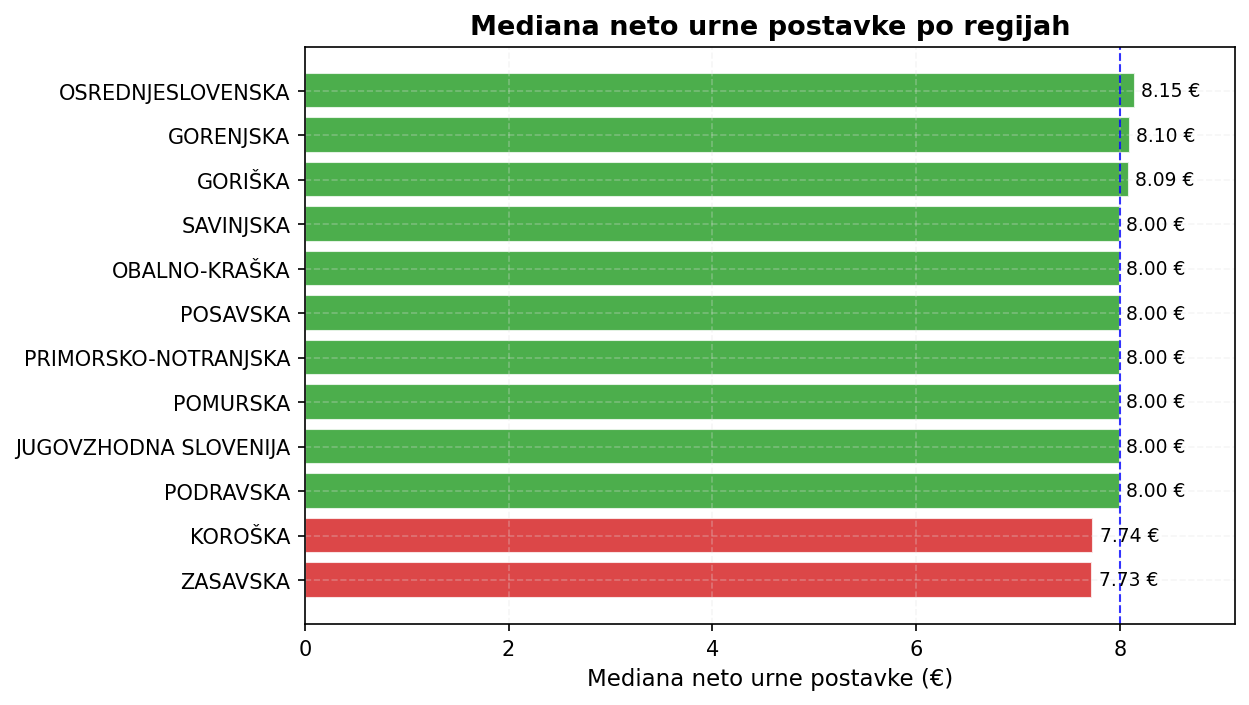

In [18]:
# Horizontalni stolpčni graf median po regijah
# Rdeče = pod skupno mediano, zeleno = nad
fig, ax = plt.subplots(figsize=(8, 5))

colors_region = [COLORS[3] if v < overall_median else COLORS[2] for v in region_pay["Mediana (€)"]]
bars = ax.barh(region_pay.index, region_pay["Mediana (€)"], color=colors_region, edgecolor="white", alpha=0.85)
ax.bar_label(bars, labels=[f"{v:.2f} €" for v in region_pay["Mediana (€)"]], padding=3, fontsize=9)

# Črtkana črta za skupno mediano z anotacijo ob spodnjem robu
ax.axvline(overall_median, color="blue", linestyle="--", linewidth=1, alpha=0.8)
#ax.annotate(f"  {overall_median:.2f} €\n  (mediana)",
#            xy=(overall_median, len(region_pay) - 0.5),
#            fontsize=8, fontstyle="italic", va="top")

ax.set_xlabel("Mediana neto urne postavke (€)")
ax.set_title("Mediana neto urne postavke po regijah")
ax.set_xlim(right=region_pay["Mediana (€)"].max() * 1.12)
plt.show()

### Ugotovitve

- Katera regija ima najvišjo mediano in ali je to pričakovano?
- Kako velika je razlika med najbolje in najslabše plačano regijo?
- Ali število oglasov v regiji vpliva na zanesljivost ocene (majhne regije z malo oglasi)?

## Vprašanje 4: Kako se trajanje študentskega dela razlikuje glede na vrsto dela?

### Opis
Raziskujemo, ali se in kako se trajanje študentskega dela razlikuje glede na vrsto dela (pridobimo najpogostejše vrste dela glede na ime npr. pomoč v trgovini, IT, strežba).

Študentom, ki si aktivno iščejo delo, lahko to pove v katerih panogah lahko preko študentskega servisa pričakujejo bolj dolgoročno delo in pri katerih delih je čas trajanja bolj prilagodljiv. 

Zanima nas:
- Ali obstajajo jasni vzorci med vrsto dela in časom trajanja? 
- Katere vrste dela so najbolj dolgotrajne?
- Pri katerih vrstah dela je čas trajanja najbolj prilagodljiv?

Uporabimo bomo atribut `duration` za določanje trajnosti dela, ter atributa `title` in `subtitle` za določanje vrste dela.  


### Analiza


In [19]:
duration = data["duration"].str.upper().fillna("")


def map_duration(d):
    if "DLJE ČASA" in d:
        return "DLJE ČASA"
    elif "PO DOGOVORU" in d:
        return "PO DOGOVORU"
    else:
        return "OSTALO"


titles = (data["title"].fillna("") + " " + data["subtitle"].fillna("")).str.upper()


def categorize(title):
    if "PROGRAMIRANJE" in title or "IT" in title:
        return "IT"
    elif "STREŽBA" in title or "KUHINJI" in title:
        return "GOSTINSTVO"
    elif "TRGOVINI" in title or "PRODAJA" in title or "BLAGAJNIK" in title:
        return "PRODAJA"
    elif "ADMINISTRATIVNA" in title or "ADMINISTRACIJA" in title:
        return "ADMINISTRACIJA"
    elif "PROIZVODNJI" in title or "PROIZVODNJA" in title:
        return "PROIZVODNJA"
    else:
        return "OSTALO"


data["category"] = titles.map(categorize)

data["trajanje"] = duration.map(map_duration)


def make_table(df):
    counts = df["trajanje"].value_counts()
    total = len(df)

    result = pd.DataFrame({
        "stevilo": counts,
        "delež (%)": (counts / total * 100).round(2)
    })

    return result


categories = ["GOSTINSTVO", "PRODAJA", "ADMINISTRACIJA", "PROIZVODNJA", "IT"]
table_data = {}
row_names = ["SPLOŠNO"] + categories
for name in row_names:
    if name == "SPLOŠNO":  #splošno -> vsa dela(da bomo imeli za primerjavo odstopanja pri specifičnih vrstah)
        df = data
    else:
        df = data[data["category"] == name]
    total = len(df)
    counts = df["trajanje"].value_counts().reindex(["DLJE ČASA", "PO DOGOVORU", "OSTALO"], fill_value=0)
    percentages = (counts / total * 100).round(2) if total > 0 else pd.Series([0.0] * 3,
                                                                              index=["DLJE ČASA", "PO DOGOVORU",
                                                                                     "OSTALO"])
    formatted = {
        "Dlje časa": f"{int(counts['DLJE ČASA'])} ({percentages['DLJE ČASA']:.2f}%)".replace(".", ","),
        "Po dogovoru": f"{int(counts['PO DOGOVORU'])} ({percentages['PO DOGOVORU']:.2f}%)".replace(".", ","),
        "Ostalo": f"{int(counts['OSTALO'])} ({percentages['OSTALO']:.2f}%)".replace(".", ","),
        "Skupaj": int(total)
    }
    table_data[name] = formatted

result_table = pd.DataFrame(table_data).T
display(result_table)

,Dlje časa,Po dogovoru,Ostalo,Skupaj
SPLOŠNO,"2978 (67,33%)","1180 (26,68%)","265 (5,99%)",4423
GOSTINSTVO,"767 (71,82%)","275 (25,75%)","26 (2,43%)",1068
PRODAJA,"351 (58,60%)","237 (39,57%)","11 (1,84%)",599
ADMINISTRACIJA,"160 (85,11%)","25 (13,30%)","3 (1,60%)",188
PROIZVODNJA,"95 (74,22%)","27 (21,09%)","6 (4,69%)",128
IT,"248 (73,37%)","76 (22,49%)","14 (4,14%)",338


### Vizualizacija

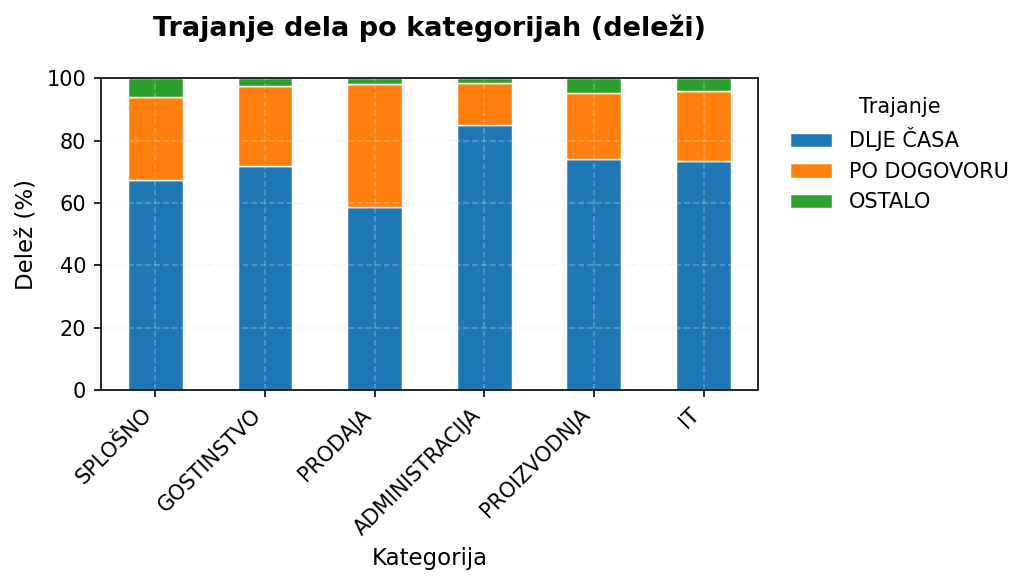

In [20]:
pivot_pct = result_table[["Dlje časa", "Po dogovoru", "Ostalo"]].copy()
#pretvorba deležev v float
pivot_pct = pivot_pct.apply(lambda col: col.astype(str)
                            .str.extract(r'\((.*?)%\)', expand=False)
                            .str.replace(',', '.')
                            .astype(float))

pivot_pct.columns = ["DLJE ČASA", "PO DOGOVORU", "OSTALO"]

category_order = ["SPLOŠNO", "GOSTINSTVO", "PRODAJA", "ADMINISTRACIJA", "PROIZVODNJA", "IT"]
pivot_pct = pivot_pct.reindex(category_order)

plot_data = pivot_pct.dropna(how='all')

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    color=COLORS[:3],
    edgecolor='white',
    linewidth=0.7
)

plt.title("Trajanje dela po kategorijah (deleži)", pad=20)
plt.xlabel("Kategorija")
plt.ylabel("Delež (%)")
plt.ylim(0, 100)

plt.legend(
    title="Trajanje",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Ugotovitve
- Katere vrste dela so najbolj dolgotrajne? 
- Katere vrste del imajo najbolj prilagodljiv čas trajanja? [prodaja]
- Ena od glavnih omejitev je, da sta na študentskem servisu samo dve glavni in dovolj številčni vrsti trajanja dela(dlje časa in po dogovoru), v primeru, da bi jih bilo več bi bila analiza lahko natančnejša   

## Vprašanje 5: Ali določeni dnevi v tednu prinašajo več novih oglasov?

### Opis
Raziskujemo, ali so določeni dnevi v tednu bolj "aktivni" za objavo novih študentskih del. Študentom, ki si aktivno iščejo delo, lahko ta informacija pomaga, da spremljajo portal ob pravih dnevih in se prijavijo med prvimi.

Uporabimo stolpec `first_seen`, tako da iz datuma izluščimo dan v tednu in izračunamo povprečno število novih oglasov za vsak dan. Izpustimo prvi dan zajema, saj je takrat scraper pobral vse obstoječe oglase.

**Hipoteza:** Med tednom (ponedeljek–petek) je več novih oglasov kot ob vikendih.

### Analiza

In [21]:
# Število novih oglasov po dnevu (first_seen = kdaj smo oglas prvič videli)
daily_new_v5 = data.groupby(data["first_seen"].dt.date).size()

# Izpustimo prvi dan — takrat je scraper pobral vse obstoječe oglase
first_day_v5 = daily_new_v5.index.min()
daily_new_v5 = daily_new_v5.drop(first_day_v5)

# 14.3.2026 (sobota) je scraper pobral petkov zajem, ker v petek ni bil pognan.
# Prestavimo te oglase na petek 13.3.2026.
from datetime import date

sat = date(2026, 3, 14)
fri = date(2026, 3, 13)
if sat in daily_new_v5.index:
    daily_new_v5[fri] = daily_new_v5.get(fri, 0) + daily_new_v5[sat]
    daily_new_v5[sat] = 0

# Ustvarimo polni date range (vključno z dnevi brez novih oglasov)
full_range = pd.date_range(daily_new_v5.index.min(), daily_new_v5.index.max(), freq="D")
daily_new_v5 = daily_new_v5.reindex(full_range.date, fill_value=0)

# Dodamo dan v tednu (0 = ponedeljek, 6 = nedelja)
daily_df = pd.DataFrame({"date": daily_new_v5.index, "count": daily_new_v5.values})
daily_df["weekday"] = pd.to_datetime(daily_df["date"]).dt.dayofweek

# Slovenska imena dni
day_names = ["Ponedeljek", "Torek", "Sreda", "Četrtek", "Petek", "Sobota", "Nedelja"]

# Povprečno število novih oglasov po dnevu v tednu (reindex da so vsi dnevi prisotni)
avg_by_day = daily_df.groupby("weekday")["count"].agg(["mean", "count"]).rename(
    columns={"mean": "Povprečje novih oglasov", "count": "Število dni v vzorcu"}
)
avg_by_day = avg_by_day.reindex(range(7), fill_value=0)
avg_by_day.index = [day_names[i] for i in avg_by_day.index]
avg_by_day["Povprečje novih oglasov"] = avg_by_day["Povprečje novih oglasov"].round(1)

display(avg_by_day)

,Povprečje novih oglasov,Število dni v vzorcu
Ponedeljek,89.5,4
Torek,98.0,4
Sreda,103.2,4
Četrtek,93.5,4
Petek,86.6,5
Sobota,0.0,4
Nedelja,0.0,4


### Vizualizacija

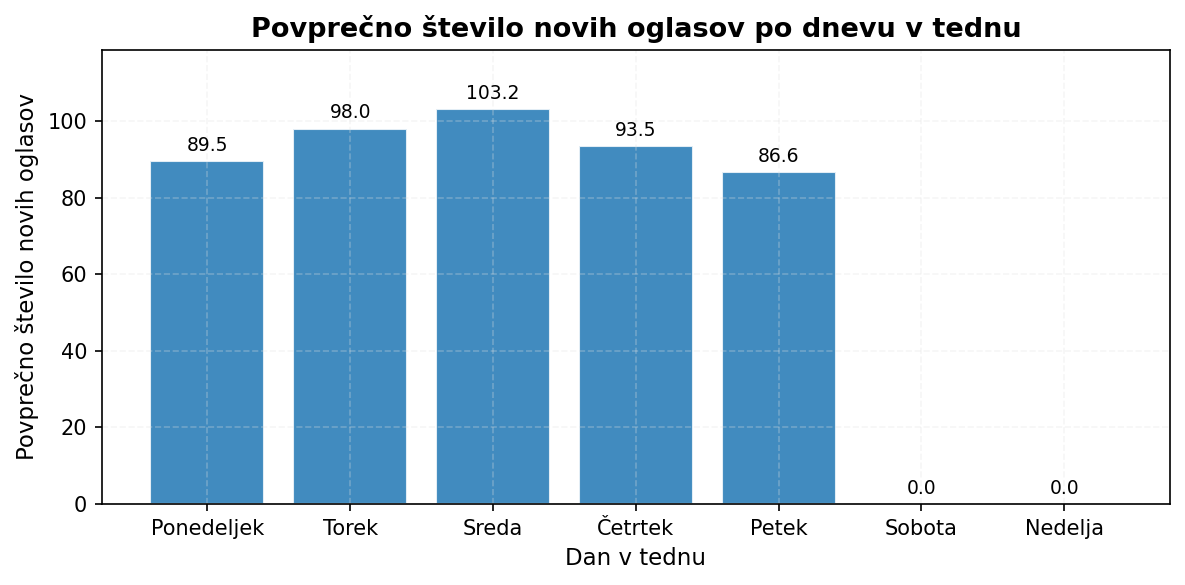

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    avg_by_day.index,
    avg_by_day["Povprečje novih oglasov"],
    color=COLORS[0],
    edgecolor="white",
    alpha=0.85,
)
ax.bar_label(bars, labels=[f"{v:.1f}" for v in avg_by_day["Povprečje novih oglasov"]], padding=3, fontsize=9)

ax.set_xlabel("Dan v tednu")
ax.set_ylabel("Povprečno število novih oglasov")
ax.set_title("Povprečno število novih oglasov po dnevu v tednu")
ax.set_ylim(top=avg_by_day["Povprečje novih oglasov"].max() * 1.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ugotovitve
- Za zapis ugotovitev moramo počakati do vsaj konca aprila, da bomo imeli zadosti rezultatov.
- Pomembno je omeniti, da določimo dan novih oglasov na podlagi `first_seen`. Z eno soboto (14.3.2026) je problem, ker smo pognali scarper v soboto, pobral pa je nove oglase za petek, ker scraper ni bil pognan v petek. Ker imamo sedaj scarper avtomatiziran, ne bo prišlo več do teh težav. Razultat ~~bomo~~ smo mogli malce prirediti, tako da ~~bomo~~ smo za to eno soboto dodali razlutate v petek.
---
- Kateri dnevi v tednu imajo največ novih oglasov?
- Ali se hipoteza potrdi, da je med tednom (pon–pet) več novih oglasov kot ob vikendih?
- Katere dni bi študentom priporočili, da redno preverjajo portal?
- Omejitev: vzorec zajema relativno kratko obdobje, zato rezultati morda niso popolnoma posplošljivi.

## Vprašanje 6: Ali dela z manj prostimi mesti ponujajo višjo plačo?

### Opis
Raziskujemo, ali obstaja povezava med številom prostih mest (`open_positions`) in povprečno neto urno postavko (`hourly_rate_neto`). Ali dela, ki imajo manj razpoložljivih delovnih mest, plačujejo več — ker so morda bolj specializirana ali zahtevna?

Filtriramo na oglase z urnim tipom plačila (`HOURLY`). Oglase razdelimo v intervale glede na število prostih mest. Kjer stolpec `open_positions` ni izpolnjen, predpostavimo 1 prosto mesto — to je smiselno, saj je najnižja eksplicitna vrednost v podatkih 2.

**Hipoteza:** Dela z manj prostimi mesti ponujajo višjo povprečno plačo.

### Analiza

In [23]:
# Filtriramo na urni tip plačila z znano plačo
df_v6 = data[
    (data["normalized_payment_type"] == "HOURLY")
    & data["hourly_rate_neto"].notna()
    ].copy()

# Kjer open_positions ni izpolnjen, predpostavimo 1 prosto mesto
df_v6["open_positions"] = df_v6["open_positions"].fillna(1)

# Intervali prostih mest
bins = [0, 1, 2, 4, 9, float("inf")]
labels = ["1", "2", "3–4", "5–9", "10+"]
df_v6["interval"] = pd.cut(df_v6["open_positions"], bins=bins, labels=labels, right=True)

# Povprečje, mediana in število oglasov po intervalu
pay_by_positions = df_v6.groupby("interval", observed=False)["hourly_rate_neto"].agg(
    ["mean", "median", "count"]
).rename(columns={"mean": "Povprečje (€)", "median": "Mediana (€)", "count": "Št. oglasov"})
pay_by_positions["Povprečje (€)"] = pay_by_positions["Povprečje (€)"].round(2)
pay_by_positions["Mediana (€)"] = pay_by_positions["Mediana (€)"].round(2)
pay_by_positions.index.name = "Prosta mesta"

display(Markdown(f"**Število vključenih oglasov:** {len(df_v6)}"))
display(pay_by_positions)

**Število vključenih oglasov:** 4120

,Povprečje (€),Mediana (€),Št. oglasov
Prosta mesta,,,
1,8.62,8.00,2193
2,8.63,8.00,1013
3–4,8.71,8.17,584
5–9,9.42,8.17,231
10+,8.93,8.17,99


### Vizualizacija

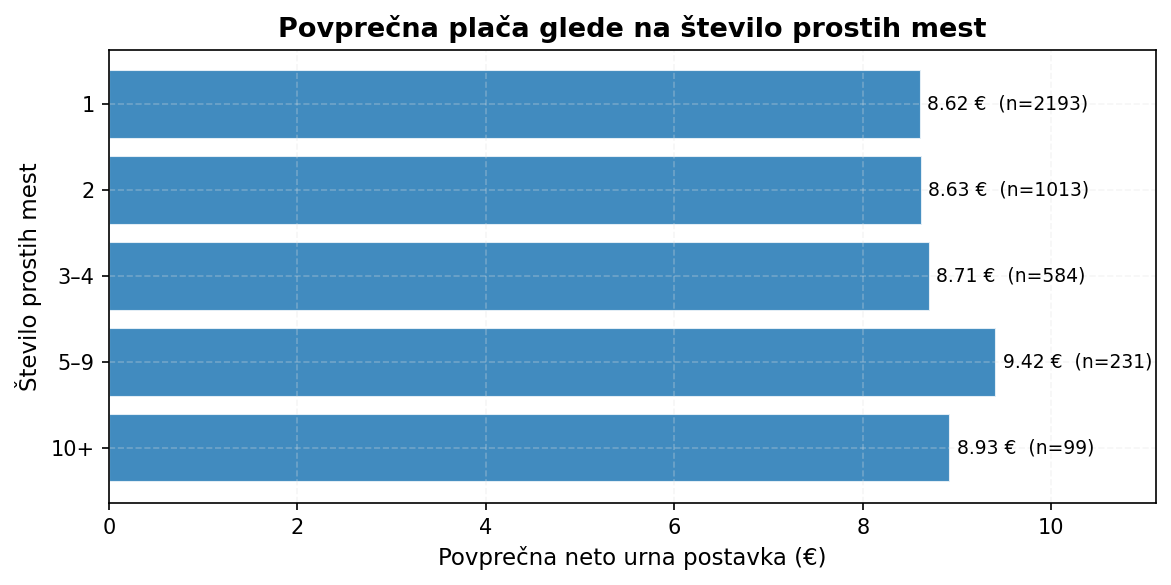

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    pay_by_positions.index,
    pay_by_positions["Povprečje (€)"],
    color=COLORS[0],
    edgecolor="white",
    alpha=0.85,
)
ax.bar_label(
    bars,
    labels=[f"{v:.2f} €  (n={n})" for v, n in zip(pay_by_positions["Povprečje (€)"], pay_by_positions["Št. oglasov"])],
    padding=3,
    fontsize=9,
)

ax.set_ylabel("Število prostih mest")
ax.set_xlabel("Povprečna neto urna postavka (€)")
ax.set_title("Povprečna plača glede na število prostih mest")
ax.set_xlim(right=pay_by_positions["Povprečje (€)"].max() * 1.18)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Ugotovitve
- Ali dela z manj prostimi mesti res ponujajo višjo plačo?
- Kako velika je razlika med intervali?
- Ali je vzorec dovolj velik v vseh intervalih za zanesljive zaključke?
- Predpostavka: oglasi brez izpolnjenega `open_positions` imajo 1 prosto mesto (najnižja eksplicitna vrednost je 2).

## Vprašanje 7: Ali se “hitro zapolnjena” dela razlikujejo po plači?

### Opis
Analiziramo, ali oglasi, ki ostanejo krajši čas aktivni na portalu (razlika med `last_seen` in `first_seen`), ponujajo višje ali nižje plačilo.

Cilj je preveriti, ali se bolje plačana dela hitreje zapolnijo in posledično hitreje izginejo iz sistema.

Omejitev: Uporabljamo samo oglase z urnim plačilom, saj omogočajo primerljivo analizo med oglasi.

### Hipoteza
Oglasi z višjo urno postavko se zapolnijo hitreje (imajo krajše trajanje).

In [25]:
# filtriramo samo oglase z urno postavko
hourly_ads = data[data["hourly_rate_neto"].notna()].copy()

# trajanje oglasa v dnevih
hourly_ads["ad_duration_days"] = (
    hourly_ads["last_seen"] - hourly_ads["first_seen"]
).dt.days

# odstrani napačne vrednosti
hourly_ads = hourly_ads[hourly_ads["ad_duration_days"] >= 0]

stats = pd.DataFrame({
    "Metrika": [
        "Število oglasov z urno postavko",
        "Povprečna plača (€)",
        "Povprečno trajanje (št. dni)",
        "Min trajanje oglasa",
        "Max trajanje oglasa"
    ],
    "Vrednost": [
        len(hourly_ads),
        hourly_ads["hourly_rate_neto"].mean().round(2),
        hourly_ads["ad_duration_days"].mean().round(2),
        hourly_ads["ad_duration_days"].min(),
        hourly_ads["ad_duration_days"].max()
    ]
})

#formatiran izpis za lažjo berljivost
display(
    stats.style
    .hide(axis="index")
    .format({"Vrednost": "{:.2f}"}, na_rep="—")
)

Metrika,Vrednost
Število oglasov z urno postavko,4120.00
Povprečna plača (€),8.69
Povprečno trajanje (št. dni),15.46
Min trajanje oglasa,0.00
Max trajanje oglasa,28.00


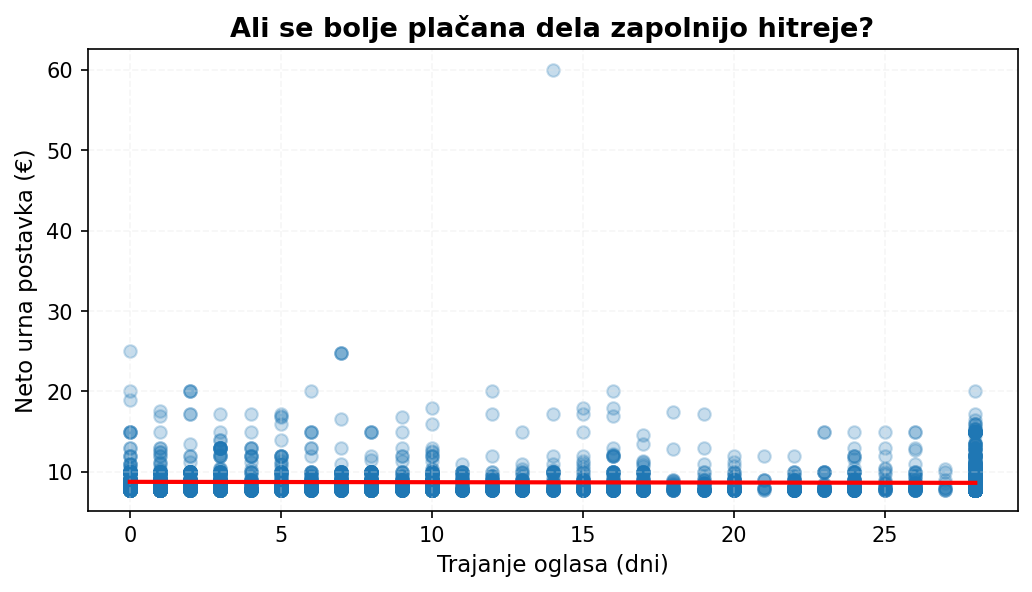

In [26]:
correlation = hourly_ads["hourly_rate_neto"].corr(hourly_ads["ad_duration_days"])

fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(
    hourly_ads["ad_duration_days"],
    hourly_ads["hourly_rate_neto"],
    alpha=0.25,
    color=COLORS[0]
)

# trend linija
z = np.polyfit(hourly_ads["ad_duration_days"], hourly_ads["hourly_rate_neto"], 1)
p = np.poly1d(z)

x_line = np.linspace(
    hourly_ads["ad_duration_days"].min(),
    hourly_ads["ad_duration_days"].max(),
    100
)

ax.plot(x_line, p(x_line), color="red", linewidth=2)

ax.set_xlabel("Trajanje oglasa (dni)")
ax.set_ylabel("Neto urna postavka (€)")
ax.set_title("Ali se bolje plačana dela zapolnijo hitreje?")

plt.show()

### Ugotovitve

- V podatkih ni opazne povezave med višino urne postavke in trajanjem oglasa.
- Korelacija je skoraj enaka 0 (-0.027), kar pomeni, da plača ne vpliva na to, kako dolgo je oglas aktiven.
- Trendna linija na grafu je skoraj popolnoma ravna, kar dodatno potrjuje odsotnost linearnega trenda.

## Vprašanje 8: Kdo obvladuje trg študentskega dela? Koncentracija oglasov med podjetji

### Opis
Analiziramo, kako so študentski oglasi porazdeljeni med podjetja.

Zanima nas, ali trg študentskega dela obvladuje nekaj velikih delodajalcev ali pa je bolj razpršen med veliko manjših podjetij.

Za analizo uporabimo Pareto princip in porazdelitev oglasov po podjetjih.

Cilj je ugotoviti:
- ali majhno število podjetij generira večino oglasov
- kako močna je koncentracija trga
- ali obstaja dolg “rep” manjših delodajalcev


In [27]:
# Število oglasov po podjetjih
company_counts = data["company"].value_counts()

total_ads = len(data)

# Koncentracija trga
top_1_share = (company_counts.head(1).sum() / total_ads) * 100
top_5_share = (company_counts.head(5).sum() / total_ads) * 100
top_10_share = (company_counts.head(10).sum() / total_ads) * 100

# Long tail analiza
one_ad_companies = (company_counts == 1).sum()
small_activity_companies = ((company_counts >= 2) & (company_counts <= 5)).sum()
high_activity_companies = (company_counts >= 6).sum()

summary = pd.DataFrame({
    "Opis": [
        "Število podjetij na platformi",
        "Delež oglasov največjega podjetja",
        "Delež oglasov top 5 podjetij",
        "Delež oglasov top 10 podjetij",
        "Podjetja z 1 oglasom",
        "Podjetja z 2–5 oglasi",
        "Podjetja z 6+ oglasi"
    ],
    "Vrednost": [
        len(company_counts),
        f"{round(top_1_share, 2)}%",
        f"{round(top_5_share, 2)}%",
        f"{round(top_10_share, 2)}%",
        one_ad_companies,
        small_activity_companies,
        high_activity_companies
    ]
})

display(summary)

,Opis,Vrednost
0,Število podjetij na platformi,2579
1,Delež oglasov največjega podjetja,4.25%
2,Delež oglasov top 5 podjetij,9.41%
3,Delež oglasov top 10 podjetij,11.69%
4,Podjetja z 1 oglasom,1880
5,Podjetja z 2–5 oglasi,637
6,Podjetja z 6+ oglasi,62


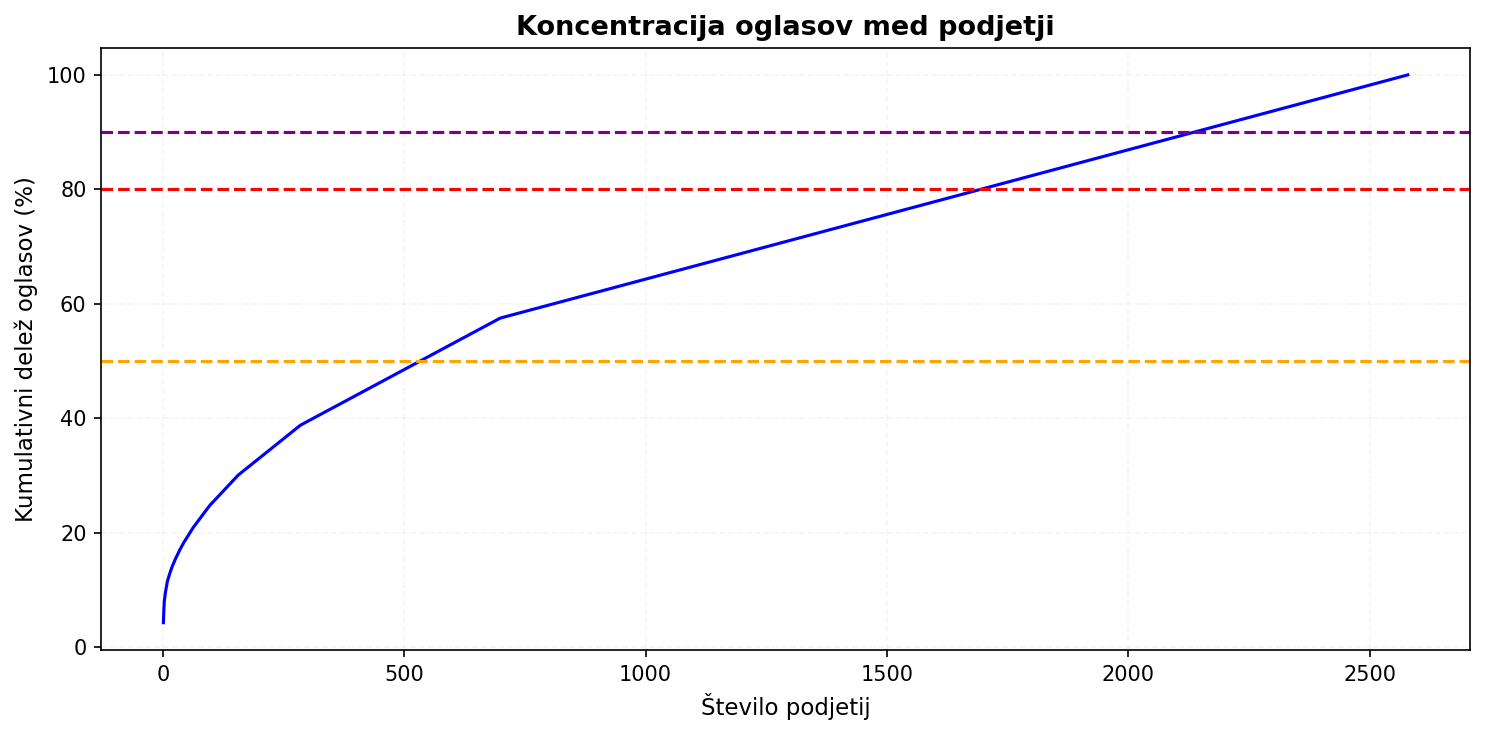

In [28]:
sorted_counts = company_counts.sort_values(ascending=False)
cum_share = sorted_counts.cumsum() / sorted_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(cum_share) + 1), cum_share.values, color="blue")

ax.set_title("Koncentracija oglasov med podjetji")
ax.set_xlabel("Število podjetij")
ax.set_ylabel("Kumulativni delež oglasov (%)")

ax.axhline(50, color="orange", linestyle="--")
ax.axhline(80, color="red", linestyle="--")
ax.axhline(90, color="purple", linestyle="--")

plt.tight_layout()
plt.show()

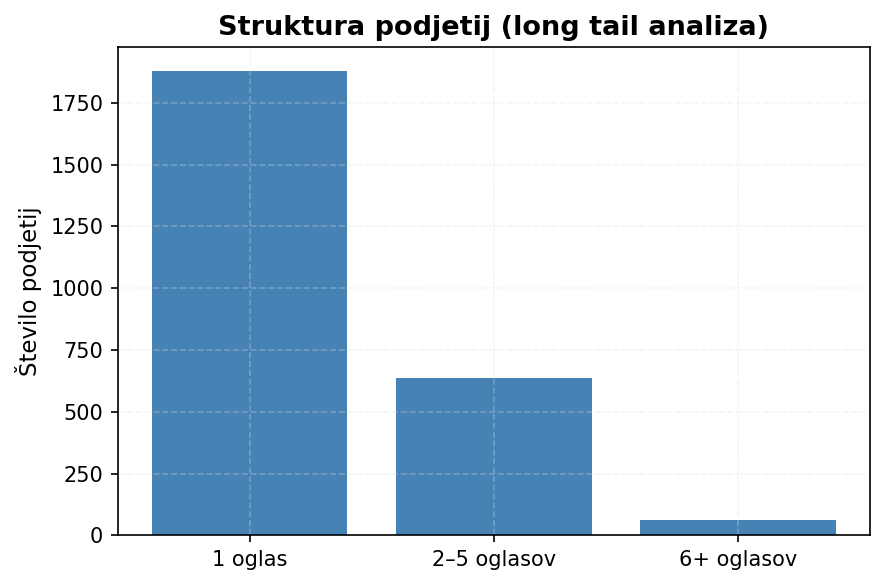

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["1 oglas", "2–5 oglasov", "6+ oglasov"],
    [one_ad_companies, small_activity_companies, high_activity_companies],
    color="steelblue"
)

ax.set_title("Struktura podjetij (long tail analiza)")
ax.set_ylabel("Število podjetij")

plt.tight_layout()
plt.show()

### Ugotovitve
- Trg je **močno razpršen na prvi pogled**, saj:
  - največje podjetje objavi le **4.25% vseh oglasov**
  - top 5 podjetij skupaj objavi **9.41% vseh oglasov**
  - top 10 podjetij skupaj objavi **11.69% vseh oglasov**

To pomeni, da **ni ekstremne monopolne dominance** (noben "super-delodajalec" ne obvladuje trga).

### Struktura podjetij
- **1880 podjetij (≈ 73%)** ima samo **1 oglas**
- **637 podjetij** ima **2–5 oglasov**
- samo **62 podjetij** ima **6 ali več oglasov**

To jasno pokaže tipično **“long-tail” strukturo trga**:
- ogromno majhnih/občasnih delodajalcev